In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def normalization(x):
 mu=np.mean(x,axis=0)
 stnd=np.std(x,axis=0)
 stnd=np.where(stnd==0,1e-10,stnd)
 x=(x-mu)/stnd
 return x

In [3]:
def ReLU(z):
 return np.maximum(z,0)

In [4]:
def softmax(z):
 ez = np.exp(z-np.max(z,axis=1,keepdims=True))
 g= ez/np.sum(ez,axis=1,keepdims=True)
 return g

In [5]:
def loss(y,a_out):
 cost=-np.mean(y * np.log(np.clip(a_out, 1e-15, 1 - 1e-15)))
 return cost

In [6]:
def initialisation(m,layer_sizes):
 w = [np.random.randn(layer_sizes[i], layer_sizes[i-1])for i in range(1, len(layer_sizes))]
 b = [np.random.randn(layer_sizes[i],1)for i in range(1,len(layer_sizes))]
 return w, b

In [7]:
def forward_prop(w,b,a_,x):
 a_[0]=x
 for k in range(len(w)-1):
  z= np.dot(a_[k],np.transpose(w[k]))+np.transpose(b[k])
  a=ReLU(z)
  a_[k+1]=a
 logits = np.dot(a_[-2],np.transpose(w[-1]))+ np.transpose(b[-1])
 a_[-1]=(softmax(logits))
 return a_

In [8]:
def one_hot(y):
 y=np.eye(len(np.unique(y)))[y]
 return y

In [9]:
def backward_prop(x,y,alpha,layer_sizes):
 y=one_hot(y)
 J_history=[]
 a_= [np.zeros((m,layer_sizes[i]))for i in range(len(layer_sizes))]
 for i in range(itrns):
  a_out=forward_prop(w,b,a_,x)
  error=a_out[-1]-y
  delta=error/m
  for j in range(len(layer_sizes) - 2, -1, -1):
   w[j] = w[j]-np.dot(delta.T,a_out[j]) * alpha
   b[j] = b[j]-(np.sum(delta, axis=0,keepdims=True)).T* alpha
   delta = np.where(a_out[j] > 0, delta.dot(w[j]), 0)
  cost=loss(y,a_out[-1])
  if i%(itrns/10)==0:
   print (f"Iteration {i}: Cost {cost}")
  J_history.append(cost)
 return w,b,a_out,J_history

In [10]:
def predict(x,a_,w,b):
 a_=forward_prop(w,b,a_,x)
 return(np.argmax(a_[-1],axis=1))

Iteration 0: Cost 3.1263614306222176
Iteration 100: Cost 0.6182997615785192
Iteration 200: Cost 0.40201616201899765
Iteration 300: Cost 0.3159315532929228
Iteration 400: Cost 0.25493049228759057
Iteration 500: Cost 0.21732970454495326
Iteration 600: Cost 0.18794423065055924
Iteration 700: Cost 0.16549607648266923
Iteration 800: Cost 0.1456205245122015
Iteration 900: Cost 0.1292597607271191
accuracy for training:0.9587142857142857
accuracy for validation:0.9185555555555556


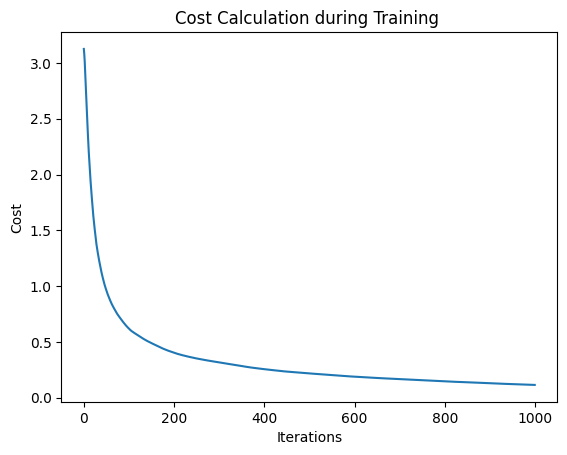

ID : 11422   label: 4
ID : 9589   label: 1
ID : 6009   label: 4
ID : 19615   label: 4
ID : 10458   label: 4
ID : 8286   label: 0
ID : 4180   label: 2
ID : 9221   label: 7
ID : 2204   label: 2
ID : 2014   label: 1
ID : 1756   label: 4
ID : 18276   label: 0
ID : 11905   label: 3
ID : 13705   label: 2
ID : 5660   label: 3
ID : 13434   label: 0
ID : 16385   label: 3
ID : 294   label: 5
ID : 7455   label: 0
ID : 14419   label: 5
ID : 5322   label: 3
ID : 3900   label: 1
ID : 18320   label: 6
ID : 19719   label: 5
ID : 8356   label: 4
ID : 6984   label: 4
ID : 3791   label: 9
ID : 6251   label: 6
ID : 12847   label: 1
ID : 7372   label: 4
ID : 10320   label: 0
ID : 12485   label: 9
ID : 1007   label: 0
ID : 3340   label: 6
ID : 5471   label: 5
ID : 19309   label: 5
ID : 8070   label: 3
ID : 17540   label: 5
ID : 2972   label: 8
ID : 19330   label: 0
ID : 8974   label: 4
ID : 13507   label: 7
ID : 9269   label: 8
ID : 9885   label: 3
ID : 17853   label: 3
ID : 1849   label: 5
ID : 1079   labe

In [13]:
df=np.array(pd.read_csv("Classification_train.csv"))
np.random.shuffle(df)
xl=df[:,1:]
xl=normalization(xl)

m,n = xl.shape
a=int(70/100*m)
xl_train=xl[:a,:]
xl_validate=xl[a:,:]

m,n=xl_train.shape
yl=df[:,0]
yl_train=yl[:a]
yl_validate=yl[a:]
itrns=1000
alpha=0.011

layer_sizes=[n,512,10]
w,b,=initialisation(m,layer_sizes)
w,b,a_,cost_history=backward_prop(xl_train,yl_train,alpha,layer_sizes)
predictions=predict(xl_train,a_,w,b)

accuracy=np.mean(yl_train==predictions)
print(f"accuracy for training:{accuracy}")
predictions=predict(xl_validate,a_,w,b)
accuracy=np.mean(yl_validate==predictions)
print(f"accuracy for validation:{accuracy}")

plt.plot(cost_history)
plt.xlabel('Iterations') 
plt.ylabel('Cost' ) 
plt.title('Cost Calculation during Training ' ) 
plt.show()

df=np.array(pd.read_csv("Classification_test.csv"))
np.random.shuffle(df)
xl=df[:,1:]
xl=normalization(xl)
m,n = xl.shape
predictions=predict(xl_train,a_,w,b)
Id=df[:,0]
for i in range(len(Id)):
 print(f"ID : {Id[i]}   label: {predictions[i]}") 